# Hafta 5 — Fourier Serileri, DFT, FFT ve Laplace Dönüşümleri

> **Bilim İnsanları ve Mühendisler için Diferansiyel Denklemler**  
> *Fourier'in ısı hilesinden Cooley-Tukey kelebeğine — her algoritma sıfırdan türetilir.*

---

## Öğrenme Hedefleri

1. **Fourier serisi** katsayılarını sinüs ve kosinüslerin dikliğinden türetmek
2. **Gibbs olayını** ve noktasal yakınsamayı analiz etmek
3. **Ayrık Fourier Dönüşümünü (DFT)** ilk ilkelerden $O(N^2)$'de uygulamak
4. **Cooley-Tukey FFT**'yi $O(N\log N)$'de türetmek ve uygulamak
5. ADD'leri çözmek ve transfer fonksiyonlarını analiz etmek için **Laplace dönüşümünü** uygulamak
6. FFT ile polinomları çarpmak için **konvolüsyon teoremini** kullanmak


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
})

---

## 1. Fourier Serileri — Türetme

$[-L, L]$ üzerinde periyodik bir $f$ fonksiyonu için, ortonormal taban $\{1, \cos(n\pi x/L), \sin(n\pi x/L)\}_{n\geq 1}$ cinsinden açın.

Diklik $\int_{-L}^{L} \cos(m\pi x/L)\cos(n\pi x/L)\,dx = L\delta_{mn}$ kullanarak:

$$\boxed{f(x) = \frac{a_0}{2} + \sum_{n=1}^{\infty}\left[a_n\cos\frac{n\pi x}{L} + b_n\sin\frac{n\pi x}{L}\right]}$$

$$a_n = \frac{1}{L}\int_{-L}^{L}f(x)\cos\frac{n\pi x}{L}\,dx, \quad b_n = \frac{1}{L}\int_{-L}^{L}f(x)\sin\frac{n\pi x}{L}\,dx$$

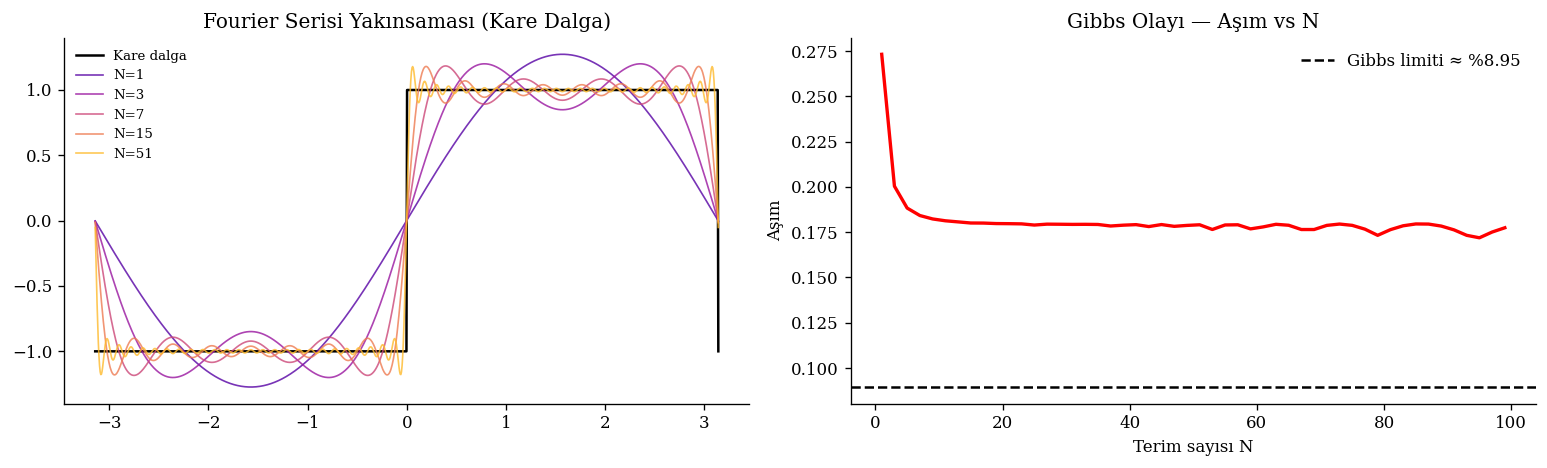

In [2]:
def fourier_katsayilari(f, L, N, n_quad=2000):
    """Sayısal kuadratür yoluyla Fourier katsayıları a_0,...,a_N, b_1,...,b_N hesaplar."""
    x = np.linspace(-L, L, n_quad, endpoint=False)
    fx = f(x)
    dx = 2*L / n_quad

    a = np.zeros(N+1)
    b = np.zeros(N+1)
    a[0] = np.sum(fx) * dx / L
    for n in range(1, N+1):
        a[n] = np.sum(fx * np.cos(n*np.pi*x/L)) * dx / L
        b[n] = np.sum(fx * np.sin(n*np.pi*x/L)) * dx / L
    return a, b


def fourier_yeniden_olusturma(a, b, L, x, N=None):
    """Fourier katsayılarından fonksiyonu yeniden oluşturur."""
    if N is None: N = len(a) - 1
    sonuc = a[0] / 2
    for n in range(1, N+1):
        sonuc = sonuc + a[n]*np.cos(n*np.pi*x/L) + b[n]*np.sin(n*np.pi*x/L)
    return sonuc


# --- Kare dalga ve Gibbs olayı ---
L = np.pi
f_kare = lambda x: np.sign(np.sin(x + 1e-10))

x_cizim = np.linspace(-L, L, 1000)
fig, eksenler = plt.subplots(1, 2, figsize=(13, 4))

eksenler[0].plot(x_cizim, f_kare(x_cizim), 'k-', lw=1.5, label='Kare dalga')
renkler = cm.plasma(np.linspace(0.15, 0.85, 5))
for N_terim, c in zip([1, 3, 7, 15, 51], renkler):
    a, b = fourier_katsayilari(f_kare, L, N_terim)
    y_yeniden = fourier_yeniden_olusturma(a, b, L, x_cizim)
    eksenler[0].plot(x_cizim, y_yeniden, color=c, lw=1, alpha=0.8, label=f'N={N_terim}')
eksenler[0].set_title('Fourier Serisi Yakınsaması (Kare Dalga)')
eksenler[0].legend(frameon=False, fontsize=8)

# Gibbs aşımı ölçümü
N_gibbs = np.arange(1, 101, 2)
asim = []
for N_t in N_gibbs:
    a, b = fourier_katsayilari(f_kare, L, N_t)
    y_yeniden = fourier_yeniden_olusturma(a, b, L, x_cizim)
    asim.append(np.max(y_yeniden) - 1.0)

eksenler[1].plot(N_gibbs, asim, 'r-', lw=2)
eksenler[1].axhline(0.0895, color='k', ls='--', label='Gibbs limiti ≈ %8.95')
eksenler[1].set_xlabel('Terim sayısı N')
eksenler[1].set_ylabel('Aşım')
eksenler[1].set_title('Gibbs Olayı — Aşım vs N')
eksenler[1].legend(frameon=False)
plt.tight_layout(); plt.show()

---

## 2. Ayrık Fourier Dönüşümü — İlk İlkelerden

$N$ karmaşık örnek $x_0, \ldots, x_{N-1}$ verildiğinde, **DFT**:

$$X_k = \sum_{n=0}^{N-1} x_n\, e^{-2\pi i kn/N}, \quad k = 0, 1, \ldots, N-1$$

Bu bir $N\times N$ matris-vektör çarpımıdır: $\mathbf{X} = W\mathbf{x}$, burada $W_{kn} = \omega^{kn}$, $\omega = e^{-2\pi i/N}$. Maliyet: $O(N^2)$.

In [3]:
def dft_naif(x):
    """Açık matris çarpımı yoluyla O(N^2) DFT."""
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(-2j * np.pi * k * n / N)
    return W @ x


def fft_cooley_tukey(x):
    """
    Radix-2 Cooley-Tukey FFT — özyinelemeli O(N log N) uygulaması.
    N, 2'nin kuvveti olmalı.
    """
    N = len(x)
    if N <= 1:
        return x
    if N % 2 != 0:
        raise ValueError('N, 2\'nin kuvveti olmalı')

    # Böl
    cift = fft_cooley_tukey(x[::2])
    tek  = fft_cooley_tukey(x[1::2])

    # Twiddle (döndürme) çarpanları
    twiddle = np.exp(-2j * np.pi * np.arange(N//2) / N)

    # Kelebek birleştirme
    return np.concatenate([
        cift + twiddle * tek,
        cift - twiddle * tek
    ])


# Doğruluk kontrolü
x_test = np.random.randn(64) + 1j * np.random.randn(64)
X_naif    = dft_naif(x_test)
X_fft     = fft_cooley_tukey(x_test)
X_numpy   = np.fft.fft(x_test)
print(f"DFT vs FFT maks hata:   {np.max(np.abs(X_naif - X_fft)):.2e}")
print(f"FFT vs NumPy maks hata: {np.max(np.abs(X_fft - X_numpy)):.2e}")

# Zamanlama karşılaştırması
N_zaman = 1024
x_buyuk = np.random.randn(N_zaman)

t0 = time.time(); dft_naif(x_buyuk); t_naif = time.time() - t0
t0 = time.time(); fft_cooley_tukey(x_buyuk); t_fft = time.time() - t0
t0 = time.time(); np.fft.fft(x_buyuk); t_np = time.time() - t0

print(f"\nN={N_zaman}:")
print(f"  Naif DFT O(N²):       {t_naif*1000:.1f} ms")
print(f"  Cooley-Tukey FFT:     {t_fft*1000:.1f} ms")
print(f"  NumPy FFT (C/FFTW):   {t_np*1000:.2f} ms")

DFT vs FFT maks hata:   2.98e-13
FFT vs NumPy maks hata: 8.34e-15

N=1024:
  Naif DFT O(N²):       57.5 ms
  Cooley-Tukey FFT:     9.7 ms
  NumPy FFT (C/FFTW):   0.22 ms


---

## 3. Spektral Analiz Uygulaması — Sinyal Ayrıştırma

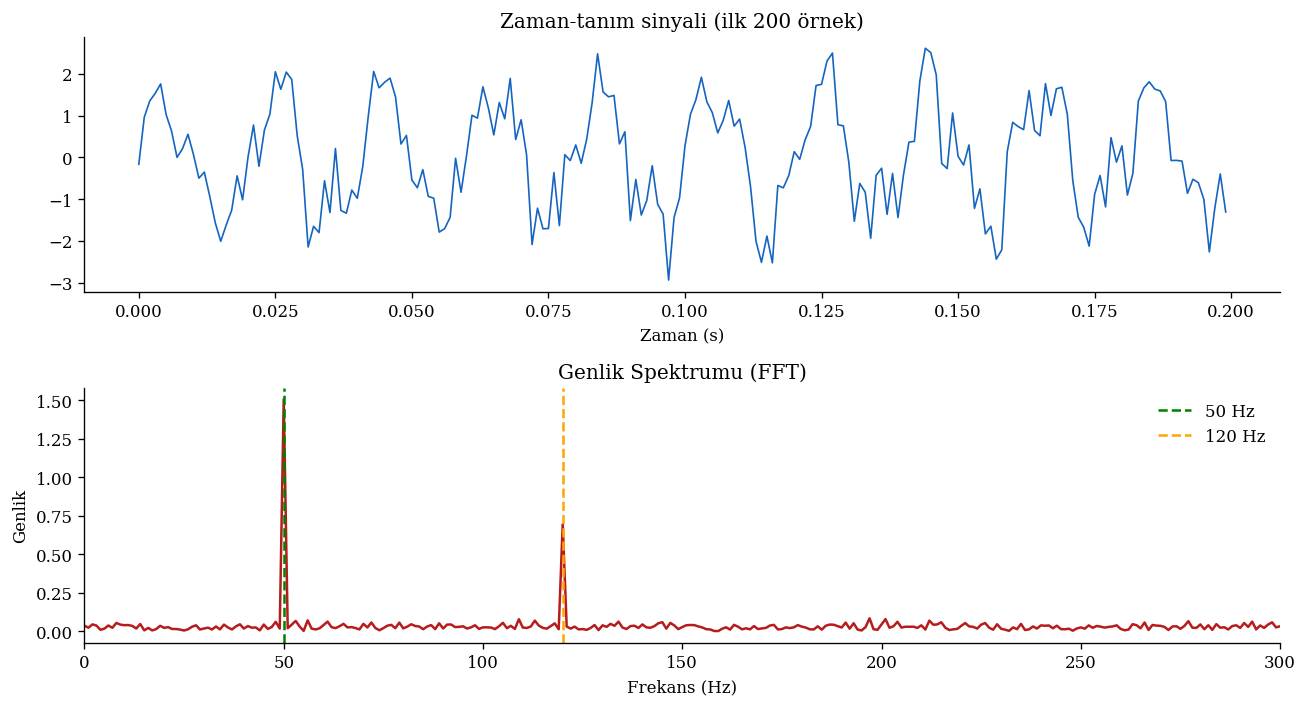

In [4]:
# Bir sinyal oluştur: iki sinüzoid + gürültü
fs = 1000        # örnekleme frekansı Hz
T_sin = 1.0      # süre saniye
t = np.linspace(0, T_sin, int(fs * T_sin), endpoint=False)

f1, f2 = 50, 120   # Hz
sinyal = (1.5*np.sin(2*np.pi*f1*t) + 0.7*np.sin(2*np.pi*f2*t) +
          0.5*np.random.randn(len(t)))

# FFT
X = np.fft.fft(sinyal)
frekanslar = np.fft.fftfreq(len(t), d=1/fs)
genlik = np.abs(X) / len(t)

# Yalnızca pozitif frekansları tut
poz = frekanslar >= 0
frekanslar_poz = frekanslar[poz]; genlik_poz = 2 * genlik[poz]

fig, eksenler = plt.subplots(2, 1, figsize=(11, 6))
eksenler[0].plot(t[:200], sinyal[:200], color='#1565C0', lw=1)
eksenler[0].set_title('Zaman-tanım sinyali (ilk 200 örnek)')
eksenler[0].set_xlabel('Zaman (s)')

eksenler[1].plot(frekanslar_poz, genlik_poz, color='#B71C1C', lw=1.5)
eksenler[1].axvline(f1, color='green', ls='--', lw=1.5, label=f'{f1} Hz')
eksenler[1].axvline(f2, color='orange', ls='--', lw=1.5, label=f'{f2} Hz')
eksenler[1].set_xlim(0, 300)
eksenler[1].set_xlabel('Frekans (Hz)'); eksenler[1].set_ylabel('Genlik')
eksenler[1].set_title('Genlik Spektrumu (FFT)')
eksenler[1].legend(frameon=False)
plt.tight_layout(); plt.show()

---

## 4. ADD'ler için Laplace Dönüşümleri

**Laplace dönüşümü** $\mathcal{L}\{f\}(s) = \int_0^\infty f(t)e^{-st}\,dt$, ADD problemlerini cebirsel problemlere dönüştürür.

ADD'leri çözmek için kullanılan temel özellikler:

| Özellik | Formül |
|---|---|
| Türev | $\mathcal{L}\{f'\} = sF(s) - f(0)$ |
| 2. Türev | $\mathcal{L}\{f''\} = s^2F(s) - sf(0) - f'(0)$ |
| Konvolüsyon | $\mathcal{L}\{f*g\} = F(s)G(s)$ |
| Frekans kayması | $\mathcal{L}\{e^{at}f\} = F(s-a)$ |

**Transfer fonksiyonu:** Sıfır BK'lı $ay'' + by' + cy = u(t)$ için, $H(s) = \frac{Y(s)}{U(s)} = \frac{1}{as^2 + bs + c}$.

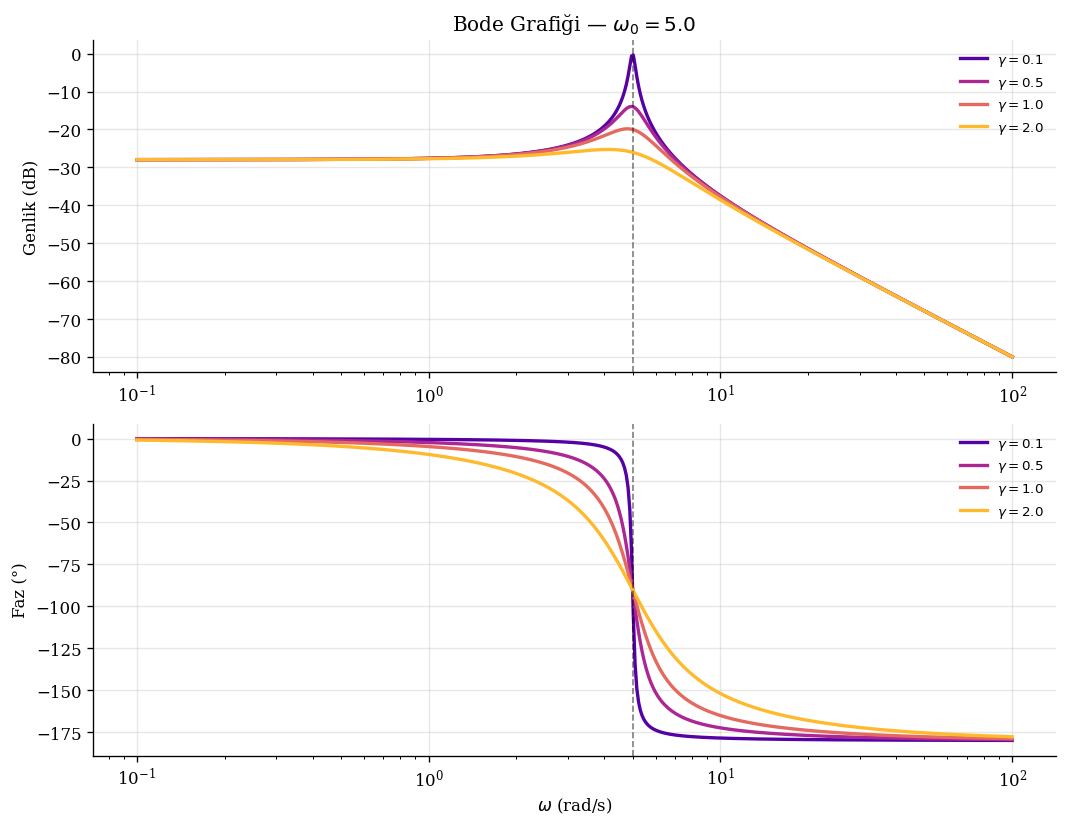

In [5]:
def bode_grafigi(pay_katsayilari, payda_katsayilari, omega_araligi=(0.01, 100), ax=None):
    """
    Bir transfer fonksiyonu H(s) için Bode genlik ve fazını hesaplar ve çizer.
    Katsayılar s'nin azalan kuvvetleriyle verilir.
    """
    omega = np.logspace(np.log10(omega_araligi[0]), np.log10(omega_araligi[1]), 500)
    s = 1j * omega
    H = np.polyval(pay_katsayilari, s) / np.polyval(payda_katsayilari, s)

    if ax is None:
        fig, ax = plt.subplots(2, 1, figsize=(9, 6))

    ax[0].semilogx(omega, 20*np.log10(np.abs(H)), 'b-', lw=2)
    ax[0].set_ylabel('Genlik (dB)'); ax[0].set_title('Bode Grafiği')
    ax[0].grid(True, alpha=0.3)

    ax[1].semilogx(omega, np.degrees(np.angle(H)), 'r-', lw=2)
    ax[1].set_xlabel('Frekans $\\omega$ (rad/s)')
    ax[1].set_ylabel('Faz (°)')
    ax[1].grid(True, alpha=0.3)
    return omega, H


# --- Sönümlü salınıcı transfer fonksiyonu: H(s) = 1 / (s^2 + 2*gamma*s + omega0^2) ---
fig, eksenler = plt.subplots(2, 1, figsize=(9, 7))
gamma_degerleri = [0.1, 0.5, 1.0, 2.0]
omega0 = 5.0
renkler = cm.plasma(np.linspace(0.15, 0.85, len(gamma_degerleri)))

for gamma, c in zip(gamma_degerleri, renkler):
    pay = [1.0]
    payda = [1.0, 2*gamma, omega0**2]
    omega = np.logspace(-1, 2, 500)
    s = 1j * omega
    H = np.polyval(pay, s) / np.polyval(payda, s)

    eksenler[0].semilogx(omega, 20*np.log10(np.abs(H)), color=c, lw=2, label=f'$\\gamma={gamma}$')
    eksenler[1].semilogx(omega, np.degrees(np.angle(H)), color=c, lw=2, label=f'$\\gamma={gamma}$')

for ax in eksenler:
    ax.axvline(omega0, color='k', ls='--', lw=1, alpha=0.5)
    ax.legend(frameon=False, fontsize=8); ax.grid(True, alpha=0.3)

eksenler[0].set_ylabel('Genlik (dB)'); eksenler[0].set_title(f'Bode Grafiği — $\\omega_0={omega0}$')
eksenler[1].set_xlabel('$\\omega$ (rad/s)'); eksenler[1].set_ylabel('Faz (°)')
plt.tight_layout(); plt.show()

---

## 5. Alıştırmalar

1. **(Fourier serisi)** $[-\pi, \pi]$ üzerindeki testere dişi dalga $f(x) = x$'in Fourier serisini analitik türetin. $N = 1, 5, 15, 50$ için kısmi toplamları çizin ve Gibbs aşımını ölçün.

2. **(Parseval teoremi)** Rastgele bir sinyal için $\sum_{n=-\infty}^{\infty}|X_n|^2 = \frac{1}{N}\sum_{k}|x_k|^2$ olduğunu sayısal doğrulayın.

3. **(Sıfırdan FFT)** Bit-ters çevirme permütasyonu kullanarak **yinelemeli** (özyinelemeli olmayan) bir Cooley-Tukey FFT uygulayın. Hızını özyinelemeli sürümle karşılaştırın.

4. **(Konvolüsyon teoremi)** İki derece-100 polinomu çarpmak için FFT kullanın. Çalışma süresini naif $O(N^2)$ polinom çarpımıyla karşılaştırın.

5. **(Laplace)** $y'' + 4y = \sin(2t)$, $y(0) = y'(0) = 0$ (rezonans) denklemini Laplace dönüşümü kullanarak çözün. Sonucu sayısal doğrulayın ve genlikteki doğrusal büyümeyi açıklayın.
